## Notebook to query Uniprot for PDB-ligand

Create Uniprot-PDB-ligand data table query by Uniprot_ID

Input:
- Any list of uniprot_ids

In [1]:
import os
import pandas as pd
import numpy as np

repo_root = !git rev-parse --show-toplevel
repo_root = repo_root[0]
os.chdir(repo_root)

query_path = "data/merged_cancer_targets_260601.csv"

df_query = pd.read_csv(query_path)

df_query.head()

,gene_name,uniprot_id,recommendedName,Pacini_in_list,oncokb_therapeutic,consmic_tier,fda_targets,pharma
0,IGH,A2N192,NaN,NaN,NaN,1.0,NaN,NaN
1,PSMB11,A5LHX3,Proteasome subunit beta type-11,True,NaN,NaN,NaN,NaN
2,HTR3E,A5X5Y0,5-hydroxytryptamine receptor 3E,True,NaN,NaN,True,NaN
3,NUTM2B,A6NNL0,NUT family member 2B,NaN,NaN,1.0,NaN,NaN
4,TUBB8B,A6NNZ2,Tubulin beta 8B,True,NaN,NaN,NaN,NaN


In [2]:
# Reformat df_query with columns: label, protein_name, uniprot_id
df_query = df_query[["pharma", "gene_name", "uniprot_id"]]

# rename columns
df_query.columns = ["label", "protein_name", "uniprot_id"]

df_query.head()


,label,protein_name,uniprot_id
0,NaN,IGH,A2N192
1,NaN,PSMB11,A5LHX3
2,NaN,HTR3E,A5X5Y0
3,NaN,NUTM2B,A6NNL0
4,NaN,TUBB8B,A6NNZ2


In [2]:
from pathlib import Path

# Hardcoded defaults for reruns and downstream notebook cells
input_txt = Path("data/query_uniprot_ids.txt")
output_csv = Path("data/all_ligands.csv")
blacklist_txt = Path("blacklist.txt")
slurm_script = Path("scripts/slurm/uniprot_to_pdb_ligand.sh")

In [49]:
import subprocess

# Write one UniProt ID per line for the batch script input
uniprot_ids = (
    df_query["uniprot_id"]
    .dropna()
    .astype(str)
    .str.strip()
)
uniprot_ids = uniprot_ids[uniprot_ids != ""]
uniprot_ids = uniprot_ids.drop_duplicates(keep="first")
input_txt.write_text("\n".join(uniprot_ids) + "\n", encoding="utf-8")

submit_cmd = [
    "sbatch",
    str(slurm_script),
    str(input_txt),
    str(output_csv),
    str(blacklist_txt),
]
result = subprocess.run(submit_cmd, check=True, capture_output=True, text=True)
print(result.stdout.strip())
print(f"Prepared {len(uniprot_ids)} unique UniProt IDs in {input_txt}")
print("Monitor logs: logs/uniprot_ligands-<jobid>.out")


Submitted batch job 54880889
Prepared 2026 unique UniProt IDs in data/query_uniprot_ids.txt
Monitor logs: logs/uniprot_ligands-<jobid>.out


In [3]:
import pandas as pd
from pathlib import Path

if not output_csv.exists():
    raise FileNotFoundError(
        f"{output_csv} not found yet. Wait for SLURM job completion, then rerun this cell."
    )

df_all = pd.read_csv(output_csv)
print(f"Loaded {len(df_all)} rows from {output_csv}")
df_all.head()

Loaded 56845 rows from data/all_ligands.csv


,uniprot_id,pdb_id,protein_chain,ligand_chain,ligand_code,ligand_name,smiles,percent_intracellular
0,O00305,2D46,NaN,NaN,NaN,NaN,NaN,NaN
1,O00291,2NO2,NaN,NaN,NaN,NaN,NaN,NaN
2,O00291,2QA7,NaN,NaN,NaN,NaN,NaN,NaN
3,O00291,3I00,NaN,NaN,NaN,NaN,NaN,NaN
4,O00220,5CIR,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Merge df_query with df_all to get the uniprot_id, gene_name, recommendedName
df_query = pd.read_csv(query_path)
df_query_metadata = df_query[["uniprot_id", "gene_name", "recommendedName"]]
df_all = pd.merge(df_query_metadata, df_all, on="uniprot_id", how="right")
df_all.head()


,uniprot_id,gene_name,recommendedName,pdb_id,protein_chain,ligand_chain,ligand_code,ligand_name,smiles,percent_intracellular
0,O00305,CACNB4,Voltage-dependent L-type calcium channel subun...,2D46,NaN,NaN,NaN,NaN,NaN,NaN
1,O00291,HIP1,Huntingtin-interacting protein 1,2NO2,NaN,NaN,NaN,NaN,NaN,NaN
2,O00291,HIP1,Huntingtin-interacting protein 1,2QA7,NaN,NaN,NaN,NaN,NaN,NaN
3,O00291,HIP1,Huntingtin-interacting protein 1,3I00,NaN,NaN,NaN,NaN,NaN,NaN
4,O00220,TNFRSF10A,Tumor necrosis factor receptor superfamily mem...,5CIR,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Function to convert smiles to molecular formula and molecular weight using RDKit
from rdkit import Chem

def smiles_to_formula(smiles):
    """Convert SMILES to molecular formula using RDKit's rdMolDescriptors."""
    from rdkit.Chem import rdMolDescriptors
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return rdMolDescriptors.CalcMolFormula(mol)

def smiles_to_mw(smiles):
    """Convert SMILES to molecular weight using RDKit's rdMolDescriptors."""
    from rdkit.Chem import rdMolDescriptors
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return rdMolDescriptors.CalcExactMolWt(mol)

def smiles_to_qed(smiles):
    """Compute QED score using RDKit's QED module."""
    from rdkit.Chem import QED
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return QED.qed(mol)

def smiles_to_num_carbon(smiles):
    """Count the number of carbon atoms in a molecule."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == 'C')

def smiles_to_num_N_O(smiles):
    """Count the number of N and O atoms in a molecule."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() in ['N', 'O'])

smiles = "O=C1NC(=O)CCC1N3C(=O)c2cccc(c2C3=O)N" # pomalidomide
print("Formula:", smiles_to_formula(smiles))
print("Exact MW:", smiles_to_mw(smiles))
print("QED:", smiles_to_qed(smiles))
print("Num Carbon:", smiles_to_num_carbon(smiles))
print("Num N and O:", smiles_to_num_N_O(smiles))

Formula: C13H11N3O4
Exact MW: 273.07495583200006
QED: 0.5375391722332333
Num Carbon: 13
Num N and O: 7


In [7]:
# Add formula and molecular weight to df_all, return None if smiles is None
def valid_smiles(s):
    return isinstance(s, str) and s.strip() != ""
df_all["formula"] = df_all["smiles"].apply(lambda s: smiles_to_formula(s) if valid_smiles(s) else None)
df_all["mw"] = df_all["smiles"].apply(lambda s: smiles_to_mw(s) if valid_smiles(s) else None)
df_all["qed"] = df_all["smiles"].apply(lambda s: smiles_to_qed(s) if valid_smiles(s) else None)
df_all["num_carbon"] = df_all["smiles"].apply(lambda s: smiles_to_num_carbon(s) if valid_smiles(s) else None)
df_all["num_N_O"] = df_all["smiles"].apply(lambda s: smiles_to_num_N_O(s) if valid_smiles(s) else None)

df_all.to_csv("all_ligands.csv", index=False)
df_all


[11:25:27] Explicit valence for atom # 0 Be, 4, is greater than permitted
[11:25:28] Explicit valence for atom # 0 B, 4, is greater than permitted
[11:25:28] Explicit valence for atom # 24 N, 4, is greater than permitted
[11:25:28] Explicit valence for atom # 25 N, 4, is greater than permitted
[11:25:28] Explicit valence for atom # 0 B, 6, is greater than permitted
[11:25:28] Explicit valence for atom # 0 B, 4, is greater than permitted
[11:25:28] Explicit valence for atom # 0 B, 4, is greater than permitted
[11:25:28] Explicit valence for atom # 0 B, 4, is greater than permitted
[11:25:28] Explicit valence for atom # 0 B, 4, is greater than permitted
[11:25:28] Explicit valence for atom # 11 N, 4, is greater than permitted
[11:25:28] Explicit valence for atom # 0 B, 4, is greater than permitted
[11:25:28] Explicit valence for atom # 21 O, 3, is greater than permitted
[11:25:28] Explicit valence for atom # 54 N, 5, is greater than permitted
[11:25:28] Explicit valence for atom # 54 N, 

,uniprot_id,gene_name,recommendedName,pdb_id,protein_chain,ligand_chain,ligand_code,ligand_name,smiles,percent_intracellular,formula,mw,qed,num_carbon,num_N_O
0,O00305,CACNB4,Voltage-dependent L-type calcium channel subun...,2D46,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
1,O00291,HIP1,Huntingtin-interacting protein 1,2NO2,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
2,O00291,HIP1,Huntingtin-interacting protein 1,2QA7,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
3,O00291,HIP1,Huntingtin-interacting protein 1,3I00,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
4,O00220,TNFRSF10A,Tumor necrosis factor receptor superfamily mem...,5CIR,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57794,Q9Y233,PDE10A,"cAMP and cAMP-inhibited cGMP 3',5'-cyclic phos...",7QQ4,A,A,EIK,"5,8-dimethyl-2-[2-(1-methyl-4-phenyl-imidazol-...",Cc1cnc(c2n1nc(n2)CCc3nc(cn3C)c4ccccc4)C,1.0,C19H20N6,332.174945,0.576376,19.0,6.0
57795,Q9Y233,PDE10A,"cAMP and cAMP-inhibited cGMP 3',5'-cyclic phos...",8DI4,A,A,S9I,"2-methyl-6-{[(1S,2S)-2-(5-methylpyridin-2-yl)c...",Cc1ccc(nc1)[C@H]2C[C@@H]2COc3cc(nc(n3)C)NCc4nn...,1.0,C19H22N6OS,382.157580,0.669676,19.0,7.0
57796,Q9Y233,PDE10A,"cAMP and cAMP-inhibited cGMP 3',5'-cyclic phos...",8XV3,B,B,A1LWO,"2,6-diazaspiro[3.3]heptan-2-yl-[2-[[4-[5-(2-me...",Cc1cc(ccn1)c2cc(nn2c3ccc(cc3)OCc4cc(c5ccccc5n4...,1.0,C32H27F3N6O2,584.214759,0.286513,32.0,8.0
57797,Q9Y233,PDE10A,"cAMP and cAMP-inhibited cGMP 3',5'-cyclic phos...",9JA8,B,B,A1L31,~{N}-(2-azanyl-2-sulfanylidene-ethyl)-2-[3-[3-...,CN(C)C(=O)c1c(nc2n1cc(cc2)F)C3CN(C3)c4cc(c5ccc...,1.0,C25H24FN7O2S,505.169622,0.387363,25.0,9.0


In [43]:
# For each unique ligand_code in df_all, check how many uniprot_id are associated with it
df_ligand_uniprot_count = df_all.groupby("ligand_code")["uniprot_id"].nunique().reset_index(name="uniprot_id_count")

# Add uniprot_id_count to df_all
df_all["uniprot_id_count"] = df_all["ligand_code"].map(df_ligand_uniprot_count.set_index("ligand_code")["uniprot_id_count"])

df_all.to_csv("all_ligands.csv", index=False)
df_all.head()

,uniprot_id,gene_name,recommendedName,pdb_id,ligand_code,ligand_name,smiles,formula,mw,qed,num_carbon,num_N_O,uniprot_id_count
0,O00291,HIP1,Huntingtin-interacting protein 1,2NO2,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
1,O00291,HIP1,Huntingtin-interacting protein 1,2QA7,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
2,O00291,HIP1,Huntingtin-interacting protein 1,3I00,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
3,O00220,TNFRSF10A,Tumor necrosis factor receptor superfamily mem...,5CIR,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
4,O00161,SNAP23,Synaptosomal-associated protein 23,1NHL,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN


In [41]:
# Filter df_all to only include these ligands
df_specific_ligands = df_all[df_all["uniprot_id_count"] == 1]

# Extract the number following 'C' in the formula (e.g., C12H10O2 would yield 12 for carbon count).
import re
def extract_carbon_count(formula):
    if not formula:
        return 0
    match = re.search(r'C(\d*)', formula)
    if not match:
        return 0
    count = match.group(1)
    return int(count) if count else 1  # If just 'C', assume 1
df_specific_ligands["num_carbon"] = df_specific_ligands["formula"].apply(extract_carbon_count)

# Remove ligands with no carbon atoms
df_specific_ligands = df_specific_ligands[df_specific_ligands["num_carbon"] > 0]

# Remove ligands with mw < 120
df_specific_ligands = df_specific_ligands[df_specific_ligands["mw"] > 120]

print(f"df_specific_ligands.shape: {df_specific_ligands.shape}")
df_specific_ligands



df_specific_ligands.shape: (9497, 13)


/tmp/ipykernel_1844958/1965213998.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_specific_ligands["num_carbon"] = df_specific_ligands["formula"].apply(extract_carbon_count)


,uniprot_id,gene_name,recommendedName,pdb_id,ligand_code,ligand_name,smiles,formula,mw,qed,num_carbon,num_N_O,uniprot_id_count
25,O00187,MASP2,Mannan-binding lectin serine protease 2,9D17,A1A1X,"2-(2-amino-1H-1,3-benzimidazol-1-yl)-N-(5-ethy...",CCc1ccc(nc1)NC(=O)Cn2c3ccccc3nc2N,C16H17N5O,295.143310,0.772422,16,6.0,1.0
26,O00187,MASP2,Mannan-binding lectin serine protease 2,9D3Y,A1A1Y,"(2S)-N-[2-(2-amino-1H-1,3-benzimidazol-5-yl)et...",c1ccc(cc1)[C@H]2CCN[C@H](C2)C(=O)N3CC[C@H]3C(=...,C25H30N6O2,446.243024,0.461840,25,8.0,1.0
27,O00187,MASP2,Mannan-binding lectin serine protease 2,9D40,A1A1Z,N-{[4-(2-amino-1H-imidazol-4-yl)phenyl]methyl}...,c1ccc(cc1)S(=O)(=O)Nc2ccc(cc2)CC(=O)NCc3ccc(cc...,C24H23N5O3S,461.152161,0.319804,24,8.0,1.0
28,O00187,MASP2,Mannan-binding lectin serine protease 2,9D4D,A1A10,"2-(2-amino-1H-1,3-benzimidazol-4-yl)-N-{4-[(py...",c1cc(c2c(c1)[nH]c(n2)N)CC(=O)Nc3ccc(cc3)Cc4ccncc4,C21H19N5O,357.158960,0.510373,21,6.0,1.0
31,O00444,PLK4,Serine/threonine-protein kinase PLK4,4JXF,631,"(1R,2S)-2-{3-[(E)-2-{4-[(dimethylamino)methyl]...",CN(C)Cc1ccc(cc1)/C=C/c2c3ccc(cc3n[nH]2)[C@@H]4...,C29H28N4O2,464.221226,0.412503,29,6.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24669,P34998,CRHR1,Corticotropin-releasing factor receptor 1,8GTG,CW9,"8-(4-bromanyl-2,6-dimethoxy-phenyl)-~{N},~{N}-...",Cc1c(c2nc(nc(n2n1)N(CCOC)CCOC)C)c3c(cc(cc3OC)B...,C21H28BrN5O4,493.132466,0.424908,21,9.0,1.0
24671,P34998,CRHR1,Corticotropin-releasing factor receptor 1,8GTI,0JS,"8-(4-bromanyl-2,6-dimethoxy-phenyl)-~{N}-butyl...",CCCCN(CC1CC1)c2nc(nc3n2nc(c3c4c(cc(cc4OC)Br)OC...,C23H30BrN5O2,487.158287,0.412485,23,7.0,1.0
24672,P34998,CRHR1,Corticotropin-releasing factor receptor 1,8GTM,0VI,"7-(4-bromanyl-2,6-dimethoxy-phenyl)-4,8-dimeth...",Cc1c(c2nc(nc(n2n1)N(CCCC(F)(F)F)CCCC(F)(F)F)C)...,C23H26BrF6N5O2,597.117406,0.242916,23,7.0,1.0
24697,P35228,NOS2,"Nitric oxide synthase, inducible",3E7G,AT2,ETHYL 4-[(4-METHYLPYRIDIN-2-YL)AMINO]PIPERIDIN...,CCOC(=O)N1CCC(CC1)Nc2cc(ccn2)C,C14H21N3O2,263.163377,0.909622,14,5.0,1.0


/tmp/ipykernel_1844958/4291995143.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


Text(0, 0.5, 'QED Score')

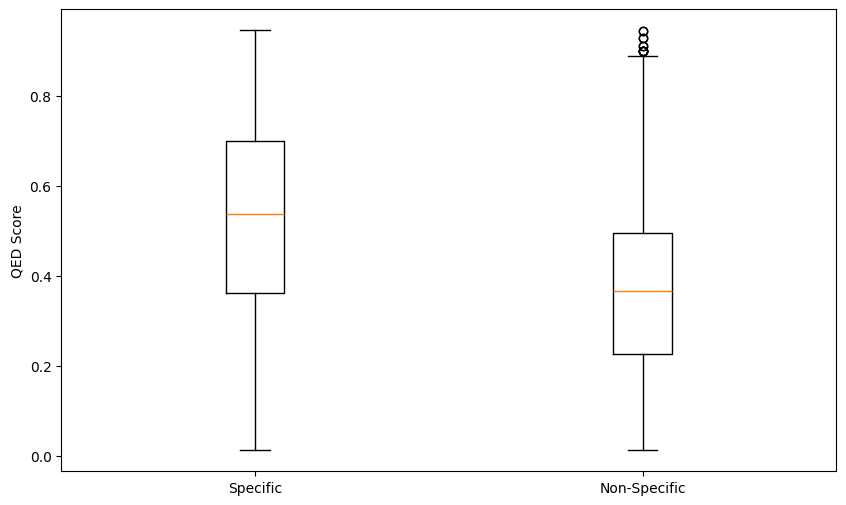

In [29]:
# Plot a boxplot comparing QED scores for specific and non-specific ligands
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.boxplot([
    df_all[df_all["specific"] == 1]["qed"].dropna(),
    df_all[df_all["specific"] == 0]["qed"].dropna()
], labels=['Specific', 'Non-Specific'])
plt.ylabel('QED Score')


___
### Filter to drug-like fragements

In [5]:
df_ligands = pd.read_csv("/scratch/ymeng/FBS_screen/all_ligands.csv")

# Filter to rows with a non empty ligand_code
df_ligands_filtered = df_ligands[df_ligands["ligand_code"].notna()]

# Filter dynamically based on filtering criteria
filtering_criteria = {
    "percent_intracellular": (0.8, 1.0),
    "mw": (100, 600),
    "qed": (0.44, 1.0),
    "num_N_O": (2, 100),
    "uniprot_id_count": (1, 2)
}

# Apply dynamic filtering
for col, (min_val, max_val) in filtering_criteria.items():
    # Drop rows where the filtering column is missing
    df_ligands_filtered = df_ligands_filtered[df_ligands_filtered[col].notna()]
    if min_val is not None:
        df_ligands_filtered = df_ligands_filtered[df_ligands_filtered[col] >= min_val]
    if max_val is not None:
        df_ligands_filtered = df_ligands_filtered[df_ligands_filtered[col] <= max_val]

print(f"df_ligands_filtered.shape: {df_ligands_filtered.shape}")
df_ligands_filtered.head()


df_ligands_filtered.shape: (8866, 16)


,uniprot_id,gene_name,recommendedName,pdb_id,protein_chain,ligand_chain,ligand_code,ligand_name,smiles,percent_intracellular,formula,mw,qed,num_carbon,num_N_O,uniprot_id_count
50,O00763,ACACB,Acetyl-CoA carboxylase 2,3FF6,C,C,RCP,(3R)-1'-(9-ANTHRYLCARBONYL)-3-(MORPHOLIN-4-YLC...,c1ccc2c(c1)cc3ccccc3c2C(=O)N4CCC(CC4)[N@]5CCC[...,1.0,C30H35N3O3,485.267842,0.522867,30.0,6.0,1.0
51,O00763,ACACB,Acetyl-CoA carboxylase 2,3GID,B,B,S1A,SORAPHEN A,C[C@H]1\C=C\[C@H]([C@H](CCCC[C@H](OC(=O)[C@H](...,1.0,C29H44O8,520.303618,0.456499,29.0,8.0,1.0
54,O00763,ACACB,Acetyl-CoA carboxylase 2,3JRX,A,A,S1A,SORAPHEN A,C[C@H]1\C=C\[C@H]([C@H](CCCC[C@H](OC(=O)[C@H](...,1.0,C29H44O8,520.303618,0.456499,29.0,8.0,1.0
55,O00763,ACACB,Acetyl-CoA carboxylase 2,3TDC,A,A,0EU,"1-[3-({4-[(5S)-3,3-dimethyl-1-oxo-2-oxa-7-azas...",CCNC(=O)Nc1c(c2ccccc2s1)C(=O)N3CCC(CC3)[N@]4CC...,1.0,C27H36N4O4S,512.245727,0.590752,27.0,8.0,1.0
88,O00311,CDC7,Cell division cycle 7-related protein kinase,4F9B,C,C,0SY,"2-(pyridin-4-yl)-1,5,6,7-tetrahydro-4H-pyrrolo...",c1cnccc1c2cc3c([nH]2)CCNC3=O,1.0,C12H11N3O,213.090212,0.751108,12.0,4.0,1.0


In [6]:
# Save df_ligands_filtered to csv
df_ligands_filtered.to_csv("drug_like_fragments.csv", index=False)
